# MOL518 Homework 4
David Godovich  
2/27/2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

# Problem 1

In [2]:
neuron_data = pd.read_csv('HW4_data/NeuronConnect.csv')

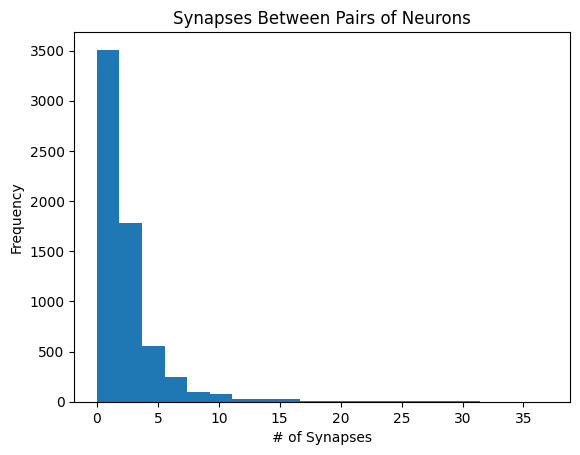

In [3]:
#a
plt.hist(neuron_data['Nbr'], bins = 20)
plt.title('Synapses Between Pairs of Neurons')
plt.xlabel('# of Synapses')
plt.ylabel('Frequency')
plt.show()

In [4]:
#b
print('Sample Mean: ', np.mean(neuron_data['Nbr']))
print('Sample Std: ', np.std(neuron_data['Nbr']))

mean_bootstrap = stats.bootstrap([neuron_data['Nbr']], np.mean, n_resamples=10000)
print(f'\nBootstrapped mean confidence interval: \n low: {mean_bootstrap.confidence_interval.low:.4f} \n high:  {mean_bootstrap.confidence_interval.high:.4f}')

std_bootstrap = stats.bootstrap([neuron_data['Nbr']], np.std, n_resamples=10000)
print(f'\nBootstrapped std confidence interval: \n low: {std_bootstrap.confidence_interval.low:.4f} \n high:  {std_bootstrap.confidence_interval.high:.4f}')

Sample Mean:  2.4894810659186537
Sample Std:  3.1641384058912787

Bootstrapped mean confidence interval: 
 low: 2.4158 
 high:  2.5729

Bootstrapped std confidence interval: 
 low: 2.9711 
 high:  3.3925


#### b
The bootstrapped confidence intervals are in a fairly small range around the observed mean. This is not surprising, since there is a large number of samples in the dataset (~6000) and this is almost fully representative of the population of neural connections in C. elegans. I will note that I am not sure that these samples are independent, since neuron connections are likely dependent on each other. Because of this, I am not sure that bootstrapping or simply looking at the mean is an effective representation of this data.

In [5]:
neuron_mean = np.mean(neuron_data['Nbr'])
neuron_var = np.var(neuron_data['Nbr'])
neuron_kurtosis = stats.kurtosis(neuron_data['Nbr'])
neuron_skew = stats.skew(neuron_data['Nbr'])

print(f'This distribution has the following summary statistics:\n mean: {neuron_mean} \n variance: {neuron_var} \n kurtosis: {neuron_kurtosis} \n skew: {neuron_skew}')

This distribution has the following summary statistics:
 mean: 2.4894810659186537 
 variance: 10.011771851636203 
 kurtosis: 28.036055133176834 
 skew: 4.535131059494816


#### c
Based on the histogram, the data appears to follow an exponential distribution. But by looking at the statistics in the above cell, it does not actually closely follow the exponential distribution. The variance of the exponential distribution is the square of the mean, which would be ~6 here; kurtosis and skew also do not line up with the expected values. Similarly, these values do not match expected values for the Poisson, binomial, or normal distributions. Therefore, this dataset is not consistent with one of the great distributions.

I referenced [the wikipedia page of the exponential distribution](https://en.wikipedia.org/wiki/Exponential_distribution) and [the poisson distribution](https://en.wikipedia.org/wiki/Poisson_distribution)

# Problem 2

In [6]:
#a
deflate_data = pd.read_csv('HW4_data/Deflategate.csv')

In [7]:
import seaborn as sns

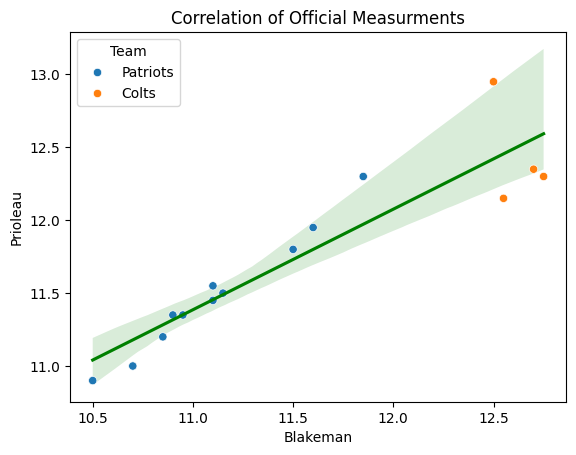

In [8]:
sns.regplot(deflate_data, x = 'Blakeman', y = 'Prioleau', scatter=False, color='g')
sns.scatterplot(deflate_data, x = 'Blakeman', y = 'Prioleau', hue = 'Team')
plt.title("Correlation of Official Measurments")
plt.show()

In [9]:
#b
pearson = stats.pearsonr(deflate_data['Blakeman'], deflate_data['Prioleau'])
spearman = stats.spearmanr(deflate_data['Blakeman'], deflate_data['Prioleau'])

print(f"Pearson coefficient is {pearson.statistic:.4f}, with a p value of {pearson.pvalue:e}")
print(f"Spearman coefficient is {spearman.statistic:.4f}, with a p value of {spearman.pvalue:e}")

Pearson coefficient is 0.9219, with a p value of 1.032552e-06
Spearman coefficient is 0.9543, with a p value of 3.407720e-08


#### b
The Pearson and Spearman correlation cofficients both measure the corelation of two datasets, in slightly different ways. Pearson is valid for linear datasets and is equivalent to the normalized covariance. Spearman is a rank based method, which makes it suitable for nonlinear data. In this case, both the Pearson and Spearman coefficients are close to 1 (0.9219 and 0.9543, respectively), and both have low p values, so we can say with high confidence that the offical's measurments are correlated.

In [10]:
#c
deflate_data['mean'] = deflate_data.mean(axis = 1, numeric_only = True)
print(deflate_data['mean'].values)

[11.65  11.025 11.325 10.85  11.275 11.775 12.075 11.325 11.15  10.7
 11.125 12.525 12.525 12.725 12.35 ]


In [11]:
#d
print('mean: ', deflate_data.groupby('Team')['mean'].mean(), '\n')
print('var: ', deflate_data.groupby('Team')['mean'].var())

mean:  Team
Colts       12.531250
Patriots    11.297727
Name: mean, dtype: float64 

var:  Team
Colts       0.023490
Patriots    0.164182
Name: mean, dtype: float64


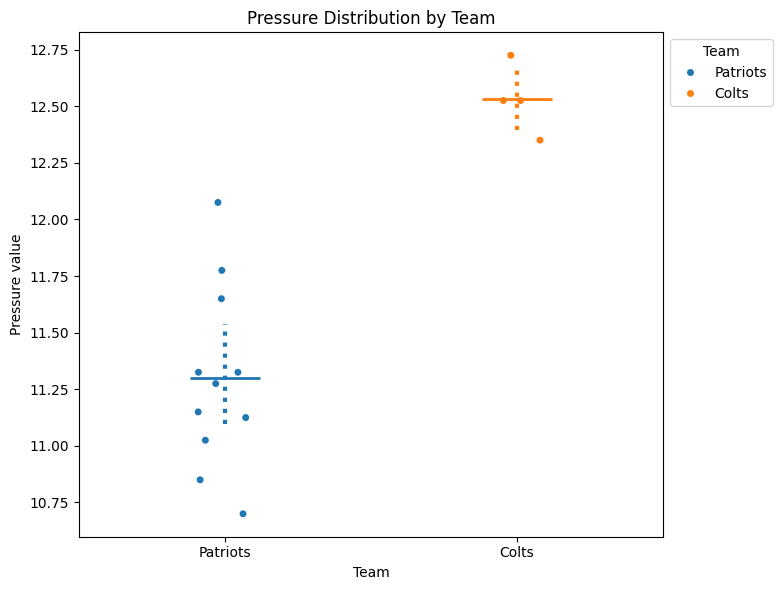

In [12]:
#e
# using 95% confidence interval for error bars
fig, ax = plt.subplots(figsize = (8,6))
ax = sns.stripplot(deflate_data, x = 'Team', y = 'mean', hue = 'Team', legend = True)
ax = sns.pointplot(
    data=deflate_data, x="Team", y="mean", hue="Team",
    linestyle="none", errorbar='ci', err_kws={'linewidth':3, 'linestyle':'dotted'},
    marker="_", markersize=50, markeredgewidth=2,
)
sns.move_legend(ax, loc = 'upper right', bbox_to_anchor = [1.2,1])
ax.set_ylabel('Pressure value')
ax.set_title('Pressure Distribution by Team')
plt.tight_layout()
plt.show()

#### e
I used a 95% confidence interval error bar to represent the spread of the mean. This is a non-parametric measurment and is only dependent on the samples in the dataset.

In [13]:
#f
official_ttest_result = stats.ttest_ind(    
    deflate_data['Blakeman'],
    deflate_data['Prioleau'],
    equal_var=False
)

team_ttest_result = stats.ttest_ind(
    deflate_data[deflate_data['Team'] == 'Patriots']['mean'],
    deflate_data[deflate_data['Team'] == 'Colts']['mean']
)

team_mannwhitney_result = stats.mannwhitneyu(
    deflate_data[deflate_data['Team'] == 'Patriots']['mean'],
    deflate_data[deflate_data['Team'] == 'Colts']['mean']
)

print(official_ttest_result, '\n')
print(team_ttest_result, '\n')
print(team_mannwhitney_result)

TtestResult(statistic=np.float64(-0.9072428768720597), pvalue=np.float64(0.37263051431490873), df=np.float64(25.93758155556955)) 

TtestResult(statistic=np.float64(-5.821183228618521), pvalue=np.float64(5.962473507175586e-05), df=np.float64(13.0)) 

MannwhitneyuResult(statistic=np.float64(0.0), pvalue=np.float64(0.004961669780653869))


#### f & g
There is no difference between officials (p value of Welch's t test is .37)  
There is a difference between teams (both t test and mann whitney are significant)

I used Welch's t test for officials because I can roughly assume that the data is normally distributed, but the variances are not equal. I used the Mann Whitney U test for teams because the sample sizes are low and do not have equal variance.

#### h
I would have had a more standardized measurment for other teams ball pressure, and taken a greater sample size to have a more accurate measure of the mean. Having more independent judges measure the ball pressure would also help to eliminate that as a possible source of error, even though the two judges in this dataset were not significantly different.

# Problem 3

In [14]:
animal_data = pd.read_csv('HW4_data/Animal-Weights.csv')

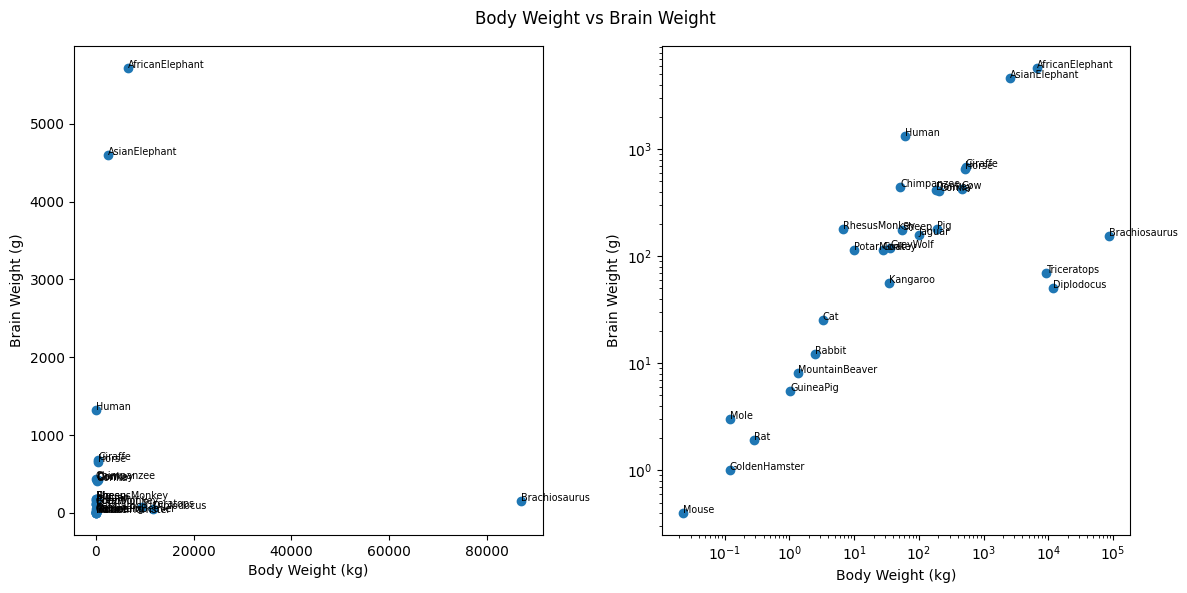

In [15]:
#b
fig, ax = plt.subplots(1,2, figsize = (12,6))
ax[0].scatter(animal_data['BodyWeight (kg)'], animal_data['BrainWeight (g)'])
for i, txt in enumerate(animal_data['Species']):
    ax[0].annotate(txt, (animal_data['BodyWeight (kg)'][i], animal_data['BrainWeight (g)'][i]), fontsize = 'x-small')
ax[0].set_xlabel('Body Weight (kg)')
ax[0].set_ylabel('Brain Weight (g)')

ax[1].scatter(animal_data['BodyWeight (kg)'], animal_data['BrainWeight (g)'])
for i, txt in enumerate(animal_data['Species']):
    ax[1].annotate(txt, (animal_data['BodyWeight (kg)'][i], animal_data['BrainWeight (g)'][i]), fontsize = 'x-small')
ax[1].set_xlabel('Body Weight (kg)')
ax[1].set_ylabel('Brain Weight (g)')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
plt.suptitle('Body Weight vs Brain Weight')
plt.tight_layout()
plt.show()

In [16]:
#c
pearson_animal = stats.pearsonr(animal_data['BodyWeight (kg)'], animal_data['BrainWeight (g)'])
spearman_animal = stats.spearmanr(animal_data['BodyWeight (kg)'], animal_data['BrainWeight (g)'])

print(f'Pearson correlation is {pearson_animal.statistic:.4f} with a pvalue of {pearson_animal.pvalue:.6f}')
print(f'Spearman correlation is {spearman_animal.statistic:.4f} with a pvalue of {spearman_animal.pvalue:.6f}')

Pearson correlation is -0.0053 with a pvalue of 0.978480
Spearman correlation is 0.7163 with a pvalue of 0.000018


#### c
Brain and weight are non linearly correlated, as shown by the values of the Spearman coefficient. The Spearman coefficient has a relatively high positive value at 0.7163, with a high degree of confidence as shown by the p value of 0.000018. The weights are not linearly correlated, as the Pearson coefficient has a value near 0 with a very high p value.

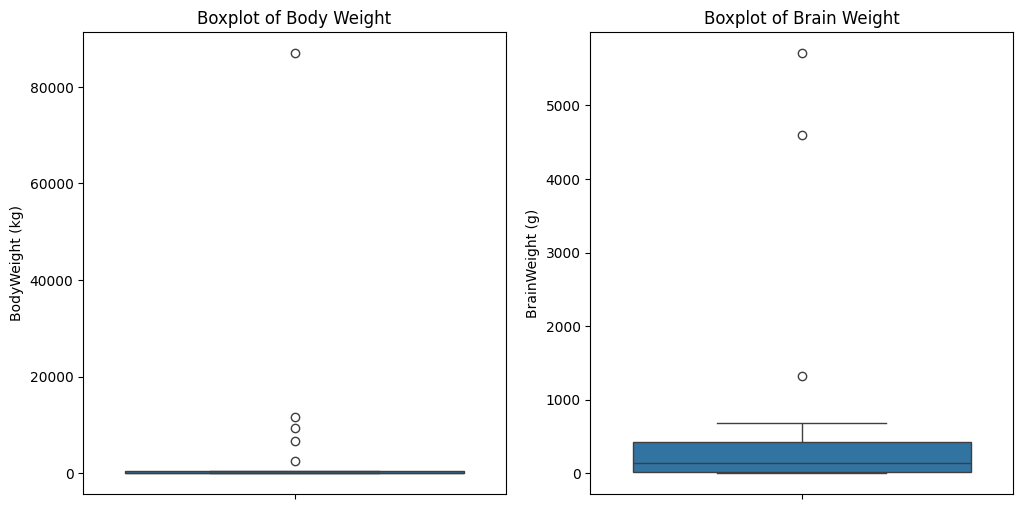

In [17]:
fig, ax = plt.subplots(1, 2, figsize = (12,6))
sns.boxplot(animal_data['BodyWeight (kg)'], ax= ax[0])
ax[0].set_title('Boxplot of Body Weight')
sns.boxplot(animal_data['BrainWeight (g)'], ax = ax[1])
ax[1].set_title('Boxplot of Brain Weight')
plt.show()

In [18]:
IQR_body = (animal_data['BodyWeight (kg)'].quantile(.75) - animal_data['BodyWeight (kg)'].quantile(.25)) * 1.5
animal_data['Species'][animal_data['BodyWeight (kg)'] > IQR_body]

5          Diplodocus
6       AsianElephant
14    AfricanElephant
15        Triceratops
25      Brachiosaurus
Name: Species, dtype: str

In [19]:
IQR_brain = (animal_data['BrainWeight (g)'].quantile(.75) - animal_data['BrainWeight (g)'].quantile(.25)) * 1.5
animal_data['Species'][animal_data['BrainWeight (g)'] > IQR_brain]

6       AsianElephant
8               Horse
11            Giraffe
13              Human
14    AfricanElephant
Name: Species, dtype: str

#### d
I think the dinosaur values are outliers since they fall outside of the line on the log-log plot. The other animals in the data are all extant animals, which have had many millions of years of evolution since the dinosaurs. Dinosaurs might be outliers because their body weight is relatively higher due to conditions present during the Mesozoic era, or that larger brains were not required for their behaviors.

By looking at a boxplot representation of the data, which plots outliers as values above 1.5*(Inter-Quartile Range), the dinosaur and elephant samples are all outliers by body weight. The elephants are more linear relative to the rest of the data, so I think they are just bigger than the other animals, rather than really being outliers. By looking at brain size, elephants are again outliers along with humans. Humans do have very large brains, but I again think elephants are simply larger than other animals.